# 🚗 HUẤN LUYỆN MODEL — Dự báo Giá & Hệ số nhân của đối thủ

**Cấu phần (ii)** · Dự án Competitor Fare Forecasting (GSM)

> **Bài toán:** cho giá đối thủ **quan sát cách đây τ phút** + ngữ cảnh → dự đoán giá và hệ số
> nhân đối thủ **đang áp dụng ngay bây giờ**. Đây là *nowcasting với quan sát bị trễ*.

| Câu hỏi | Trả lời |
|---|---|
| Model gì? | **Gradient Boosting Decision Trees** (`HistGradientBoosting`, scikit-learn) |
| Có phải ML không? | ✅ Học máy **có giám sát** |
| Train ở đâu? | Cục bộ trên máy này, bằng CPU |
| Vì sao cây, không neural network? | Dữ liệu **dạng bảng**; cây **giải thích được**, xử lý NaN & categorical native |

**Dữ liệu đầu vào:** `data/snapshot_price_15min.parquet`, `data/snapshot_surge_15min.parquet`
→ sinh bởi `model/data_preparation.py` (chạy trước notebook này).

---

## Mục lục
1. Chạy xem thông tin data
2. Phân chia dữ liệu train / test
3. Setup mô hình ban đầu
4. Quá trình huấn luyện
5. Kết quả thu được
6. Đánh giá
7. Test với tập test

In [13]:
# ============ NAP THU VIEN ============
import warnings, time, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             roc_auc_score, average_precision_score, brier_score_loss)
import joblib

warnings.filterwarnings("ignore")
%matplotlib inline

# Bang mau thong nhat
BLUE, ORANGE, GREEN, RED, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#666666"
MAU_HANG = {"Uber": BLUE, "Lyft": RED}
plt.rcParams.update({"figure.facecolor":"white", "axes.facecolor":"white",
                     "axes.spines.top":False, "axes.spines.right":False,
                     "axes.grid":True, "grid.color":"#ECECEC", "font.size":10})
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)

DATA = Path("../data"); OUT = Path(".")
print("San sang.")

San sang.


---
# 1️⃣ Chạy xem thông tin data

Nạp 2 bảng snapshot và xem: kích thước, số chuỗi (series), khoảng thời gian, phân bố target,
tỷ lệ thiếu lag, phân bố độ trễ quan sát.

In [14]:
# Nap 2 bang snapshot
gp = pd.read_csv(DATA/"snapshot_price_15min.csv", parse_dates=["snapshot"])   # bang GIA  (cap cuoc)
gs = pd.read_csv(DATA/"snapshot_surge_15min.csv", parse_dates=["snapshot"])   # bang SURGE (cap thi truong)

print(f"BANG GIA  : {len(gp):>8,} dong x {gp.shape[1]} cot")
print(f"BANG SURGE: {len(gs):>8,} dong x {gs.shape[1]} cot")
print()
print(f"Thoi gian: {gp.snapshot.min()}  ->  {gp.snapshot.max()}")
print(f"So series GIA  : {gp.groupby(['cab_type','source','destination','name'], observed=True).ngroups:,}")
print(f"So series SURGE: {gs.groupby(['source','destination'], observed=True).ngroups:,}")
display(gp.head(3))

BANG GIA  :  471,649 dong x 36 cot
BANG SURGE:   66,445 dong x 36 cot

Thoi gian: 2018-11-25 22:30:00  ->  2018-12-18 14:15:00
So series GIA  : 864
So series SURGE: 72


,cab_type,source,destination,name,snapshot,target_price,price_min,price_max,distance_median,quote_count,temperature,precipIntensity,precipProbability,humidity,windSpeed,visibility,cloudCover,short_summary,price_spread,hour_local,weekday_local,is_weekend,hour_sin,hour_cos,lag1_price,lag2_price,lag3_price,delta_price_1_2,roll_mean3_price,roll_mean6_price,roll_std3_price,lag1_quote_count,so_quan_sat_truoc,observation_age_minutes,observation_age_bucket,data_split
0,Lyft,Back Bay,Boston University,Lux,2018-11-25 23:45:00,13.5,13.5,13.5,1.45,2,41.52,0.0,0.0,0.90,0.45,4.159,1.0,Overcast,0.0,23,6,1,-0.258819,0.965926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,train
1,Lyft,Back Bay,Boston University,Lux,2018-11-26 00:00:00,13.5,13.5,13.5,1.45,1,41.99,0.0,0.0,0.91,0.53,4.675,1.0,Overcast,0.0,0,0,0,0.000000,1.000000,13.5,NaN,NaN,NaN,13.5,13.5,NaN,2.0,1,15.0,<=15p,train
2,Lyft,Back Bay,Boston University,Lux,2018-11-26 02:15:00,13.5,13.5,13.5,1.49,1,42.02,0.0,0.0,0.91,2.01,6.397,1.0,Overcast,0.0,2,0,0,0.500000,0.866025,13.5,13.5,NaN,0.0,13.5,13.5,0.0,1.0,2,135.0,1-3h,train


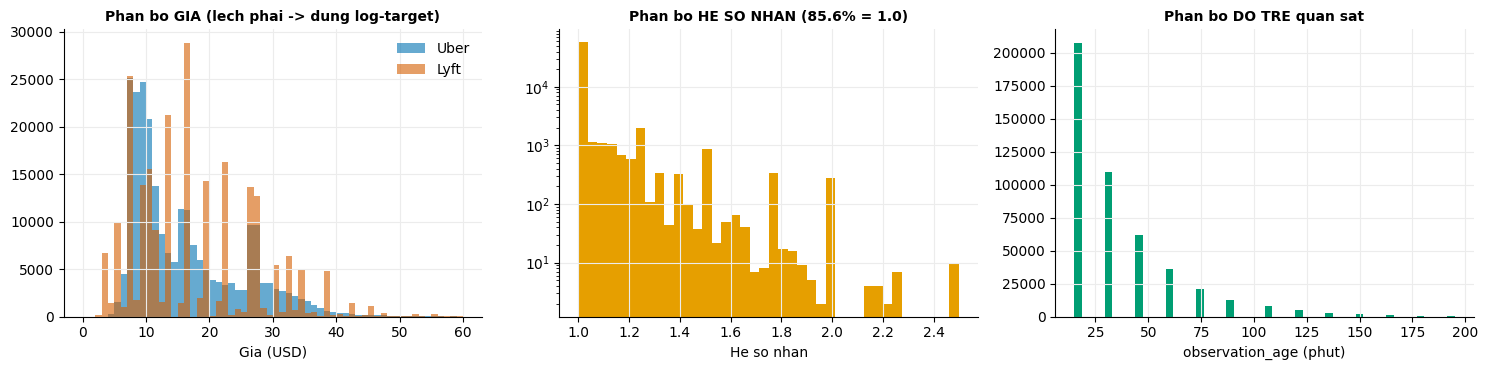

Ty le co surge: 14.45%  <- MAT CAN BANG -> KHONG dung accuracy
Do tre quan sat: median=30 phut | p90=75 phut


In [15]:
# Phan bo 2 target + do tre
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

for hang in ["Uber","Lyft"]:
    ax[0].hist(gp[gp.cab_type==hang].target_price, bins=60, range=(0,60),
               alpha=.6, label=hang, color=MAU_HANG[hang])
ax[0].set_title("Phan bo GIA (lech phai -> dung log-target)", fontweight="bold", fontsize=10)
ax[0].set_xlabel("Gia (USD)"); ax[0].legend(frameon=False)

ax[1].hist(gs.target_surge, bins=40, color=ORANGE); ax[1].set_yscale("log")
ax[1].set_title(f"Phan bo HE SO NHAN ({(gs.target_is_surge==0).mean()*100:.1f}% = 1.0)",
                fontweight="bold", fontsize=10)
ax[1].set_xlabel("He so nhan")

age = gp.observation_age_minutes.dropna()
ax[2].hist(age[age<200], bins=50, color=GREEN)
ax[2].set_title("Phan bo DO TRE quan sat", fontweight="bold", fontsize=10)
ax[2].set_xlabel("observation_age (phut)")
plt.tight_layout(); plt.show()

print(f"Ty le co surge: {gs.target_is_surge.mean()*100:.2f}%  <- MAT CAN BANG -> KHONG dung accuracy")
print(f"Do tre quan sat: median={age.median():.0f} phut | p90={age.quantile(.9):.0f} phut")

In [16]:
# Thieu du lieu o cot lag (dong dau moi series khong co lag)
print("Ty le THIEU (%) o cac cot lag/rolling — bang GIA:")
display((gp.filter(regex="^(lag|roll|delta)").isna().mean()*100).round(2).to_frame("thieu_%"))

# ================= KIEM TRA CHONG RO RI =================
k = ["cab_type","source","destination","name"]

# (1) lag1 phai den tu quan sat STRICTLY TRUOC DO -> observation_age > 0
print("[1] observation_age > 0 tren toan bang ? ->", (age.dropna()>0).all())  # bo NaN o dong dau series

# (2) lag1 == target_price cua snapshot lien truoc, KIEM TRA TRONG TUNG SPLIT.
#     Luu y: phai kiem trong tung split, vi giua train va calibration co 2 ngay
#     buffer (11-12/12) bi loai khoi bang. Dong dau cua series o 13/12 co lag1
#     tro ve ngay 11-12/12 -> van la QUA KHU that, khong phai ro ri.
for sp in ["train","calibration","test"]:
    s = gp[gp.data_split==sp].sort_values(k+["snapshot"]).copy()
    s["chk"] = s.groupby(k, observed=True).target_price.shift(1)
    m = s.lag1_price.notna() & s.chk.notna()
    ok = np.allclose(s.lag1_price[m], s.chk[m])
    print(f"[2] [{sp:12}] lag1 == shift(1) trong split -> {ok}  (n={m.sum():,})")

# (3) Khong duoc dung bat ky cot nao tinh TAI t
print("[3] Cot CAM dung lam feature (tinh tai t): target_price, price_min/max/spread, quote_count")

Ty le THIEU (%) o cac cot lag/rolling — bang GIA:


,thieu_%
lag1_price,0.18
lag2_price,0.37
lag3_price,0.55
delta_price_1_2,0.37
roll_mean3_price,0.18
roll_mean6_price,0.18
roll_std3_price,0.37
lag1_quote_count,0.18


[1] observation_age > 0 tren toan bang ? -> True
[2] [train       ] lag1 == shift(1) trong split -> True  (n=288,407)
[2] [calibration ] lag1 == shift(1) trong split -> True  (n=96,833)
[2] [test        ] lag1 == shift(1) trong split -> True  (n=83,817)
[3] Cot CAM dung lam feature (tinh tai t): target_price, price_min/max/spread, quote_count


---
# 2️⃣ Phân chia dữ liệu train / test

**Chia theo THỜI GIAN, tuyệt đối không chia ngẫu nhiên.** Đây là bài toán dự báo — chia ngẫu
nhiên sẽ để model "nhìn thấy tương lai" → kết quả đẹp giả tạo, sập khi chạy thật.

| Tập | Khoảng thời gian | Dùng để |
|---|---|---|
| **train** | 25/11 → 10/12 | Huấn luyện model |
| **calibration** | 13/12 → 15/12 | Dành cho cấu phần (iii) — Conformal Prediction |
| **test** | 16/12 → 18/12 | Đánh giá cuối, model **chưa từng thấy** |

Cột `data_split` đã được gán sẵn ở bước `data_preparation.py`.

In [17]:
def xem_split(g, ten):
    tab = g.groupby("data_split").agg(so_dong=("snapshot","size"),
                                      tu_ngay=("snapshot","min"), den_ngay=("snapshot","max"))
    tab = tab.reindex([x for x in ["train","calibration","test"] if x in tab.index])
    tab["ty_le_%"] = (tab.so_dong/len(g)*100).round(1)
    print(f"=== {ten} ==="); display(tab)
    tr_max = g[g.data_split=="train"].snapshot.max()
    te_min = g[g.data_split=="test"].snapshot.min()
    print(f"  train ket thuc {tr_max}  <  test bat dau {te_min}  ->  KHONG chong lan: {tr_max < te_min}")
    print()

xem_split(gp, "BANG GIA"); xem_split(gs, "BANG SURGE")

=== BANG GIA ===


,so_dong,tu_ngay,den_ngay,ty_le_%
data_split,,,,
train,289271,2018-11-25 22:30:00,2018-12-09 21:30:00,61.3
calibration,97697,2018-12-13 00:00:00,2018-12-15 23:45:00,20.7
test,84681,2018-12-16 00:00:00,2018-12-18 14:15:00,18.0


  train ket thuc 2018-12-09 21:30:00  <  test bat dau 2018-12-16 00:00:00  ->  KHONG chong lan: True

=== BANG SURGE ===


,so_dong,tu_ngay,den_ngay,ty_le_%
data_split,,,,
train,39761,2018-11-25 22:30:00,2018-12-09 21:30:00,59.8
calibration,14330,2018-12-13 00:00:00,2018-12-15 23:45:00,21.6
test,12354,2018-12-16 00:00:00,2018-12-18 14:15:00,18.6


  train ket thuc 2018-12-09 21:30:00  <  test bat dau 2018-12-16 00:00:00  ->  KHONG chong lan: True



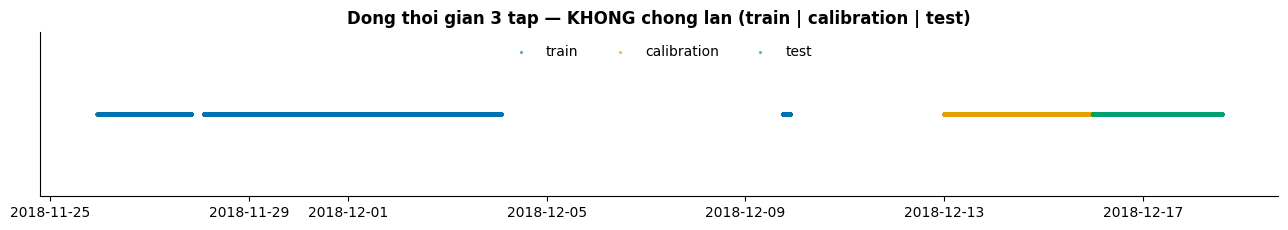

In [18]:
# Truc quan hoa dong thoi gian 3 tap
fig, ax = plt.subplots(figsize=(13, 2.4))
for s, c in [("train",BLUE), ("calibration",ORANGE), ("test",GREEN)]:
    d = gp[gp.data_split==s]
    ax.scatter(d.snapshot, np.zeros(len(d)), s=2, color=c, label=s, alpha=.5)
ax.set_yticks([]); ax.legend(frameon=False, ncol=3, loc="upper center")
ax.set_title("Dong thoi gian 3 tap — KHONG chong lan (train | calibration | test)",
             fontweight="bold"); ax.grid(False)
plt.tight_layout(); plt.show()

### Bộ feature — nguyên tắc chống rò rỉ

Tại mốc **t**, chỉ được dùng: ngữ cảnh biết trước + lag từ **t−1 trở về trước**.

❌ **Cấm tuyệt đối:** `target_price` tại t, `price_min/max/spread`, `quote_count` tại t
(đều tính tại t → nhìn lén hiện tại).

❌ **Đã loại từ phân tích tuần 1:** `cab_type` (trùng `name`), `moonPhase`/`pressure`/`ozone`
(proxy ngày), `latitude`/`longitude` (lệch hàng), `price_per_mile` (nhiễu quãng đường),
weather cho model giá (chỉ ~5%, lẫn hiệu ứng ngày).

In [19]:
# ---- BO FEATURE (theo docs/MODEL_DESIGN.md) ----
PRICE_CAT = ["name", "source", "destination", "observation_age_bucket"]
PRICE_NUM = ["distance_median", "lag1_price", "lag2_price", "lag3_price",
             "roll_mean6_price", "roll_std3_price", "observation_age_minutes",
             "hour_local", "weekday_local", "is_weekend"]

SURGE_CAT = ["source", "destination", "short_summary"]
SURGE_NUM = ["hour_local", "weekday_local", "is_weekend",
             "lag1_surge", "lag2_surge", "roll_mean6_surge", "roll_surge_rate6",
             "observation_age_minutes"]

PRICE_FEATS = PRICE_CAT + PRICE_NUM
SURGE_FEATS = SURGE_CAT + SURGE_NUM

CAM = {"target_price","target_surge","target_is_surge",
       "price_min","price_max","price_spread","quote_count"}
assert not set(PRICE_FEATS) & CAM, "CO FEATURE RO RI trong model GIA!"
assert not set(SURGE_FEATS) & CAM, "CO FEATURE RO RI trong model SURGE!"

print(f"Model GIA  : {len(PRICE_FEATS)} feature ({len(PRICE_CAT)} categorical)")
print(f"Model SURGE: {len(SURGE_FEATS)} feature ({len(SURGE_CAT)} categorical)")
print("[OK] Khong co feature ro ri.")

def prep(df, cat):
    X = df.copy()
    for c in cat:
        X[c] = X[c].astype("category")
    return X

Model GIA  : 14 feature (4 categorical)
Model SURGE: 11 feature (3 categorical)
[OK] Khong co feature ro ri.


---
# 3️⃣ Setup mô hình ban đầu

### Thuật toán: HistGradientBoosting
Model **không phải neural network** nên **không có epoch**. Gradient boosting xây **cây tuần
tự** — mỗi cây mới sửa lỗi (residual) của các cây trước. Số cây (`max_iter`) đóng vai trò như
"số vòng lặp".

| Tham số | Giá trị | Ý nghĩa |
|---|---|---|
| `max_iter` | 500 | Số cây tối đa (= số vòng boosting) |
| `learning_rate` | 0,05 | Mỗi cây đóng góp bao nhiêu (nhỏ = học chậm, chắc) |
| `l2_regularization` | 1,0 | Phạt độ phức tạp → chống overfit |
| `early_stopping` | True | Tự dừng khi validation không cải thiện |
| `validation_fraction` | 0,1 | 10% tập train tách ra làm validation nội bộ |
| `categorical_features` | 4 cột | Xử lý categorical native, không cần one-hot |

### Ba lựa chọn thiết kế quan trọng

1. **Log-target cho giá** — giá lệch phải, `log` làm phân phối cân đối → giảm MAE ~5%.
2. **Train riêng từng hãng** — Uber/Lyft khác công thức giá (đơn giá/dặm chênh tới 11,5%).
3. **Model surge 2 tầng** — 86,5% giá trị = 1.0, hồi quy thẳng thua cả hằng số. Tách thành
   `P(có surge)` × `E[độ lớn | có surge]`.

In [20]:
# ---- SETUP MODEL GIA ----
def tao_model_gia():
    return HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.05, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
        categorical_features=PRICE_CAT, random_state=42)

# ---- SETUP MODEL SURGE (2 tang) ----
def tao_model_surge_clf():
    return HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
        categorical_features=SURGE_CAT, random_state=42)

def tao_model_surge_reg():
    return HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, l2_regularization=1.0,
        categorical_features=SURGE_CAT, random_state=42)

print(tao_model_gia())

HistGradientBoostingRegressor(categorical_features=['name', 'source',
                                                    'destination',
                                                    'observation_age_bucket'],
                              early_stopping=True, l2_regularization=1.0,
                              learning_rate=0.05, max_iter=500,
                              n_iter_no_change=20, random_state=42)


### Baseline — mốc BẮT BUỘC phải vượt

Một con số MAE vô nghĩa nếu không đặt cạnh baseline:
- **Persistence:** lấy y hệt giá quan sát gần nhất (`lag1`) — "cứ dùng giá cũ", 0 ML.
- **Historical-average:** trung bình 6 quan sát gần nhất (`roll_mean6`) — thuần công thức.

> ⚠️ Với giá, **historical-average thắng persistence** ở cả 2 hãng → mốc thật để vượt là
> historical-avg, không phải persistence.

In [21]:
print("BASELINE GIA (tren tap TEST):")
print(f"  {'Hang':<8}{'Persistence':>14}{'Historical-avg':>18}")
base_price = {}
for hang in ["Uber","Lyft"]:
    te = gp[(gp.cab_type==hang) & (gp.data_split=="test")]
    b1, b2 = te.lag1_price.notna(), te.roll_mean6_price.notna()
    per = mean_absolute_error(te.target_price[b1], te.lag1_price[b1])
    his = mean_absolute_error(te.target_price[b2], te.roll_mean6_price[b2])
    base_price[hang] = {"persistence": per, "histavg": his}
    print(f"  {hang:<8}{per:>13.3f}{his:>17.3f}")

te_s = gs[gs.data_split=="test"]
base_surge_auc = roc_auc_score(te_s.target_is_surge, (te_s.lag1_surge.fillna(1)-1).clip(0))
base_surge_mae = mean_absolute_error(te_s.target_surge, np.ones(len(te_s)))
print()
print(f"BASELINE SURGE: AUC persistence={base_surge_auc:.4f} | MAE 'luon 1.0'={base_surge_mae:.4f}")

BASELINE GIA (tren tap TEST):
  Hang       Persistence    Historical-avg
  Uber            1.683            1.325
  Lyft            2.125            1.775

BASELINE SURGE: AUC persistence=0.5181 | MAE 'luon 1.0'=0.0396


---
# 4️⃣ Quá trình huấn luyện

Train **3 model**: giá Uber, giá Lyft, surge Lyft (2 tầng). Chỉ dùng tập **train**;
tập test giữ nguyên cho bước 7.

In [22]:
# ================= TRAIN MODEL GIA =================
models, tests = {}, {}
print("="*64); print("TRAIN MODEL GIA (log-target, early stopping)"); print("="*64)

for hang in ["Uber","Lyft"]:
    d  = gp[gp.cab_type==hang]
    tr = d[d.data_split=="train"]     # <-- CHI dung TRAIN de hoc
    te = d[d.data_split=="test"]      # <-- giu nguyen cho buoc 7

    t0 = time.time()
    m = tao_model_gia()
    m.fit(prep(tr, PRICE_CAT)[PRICE_FEATS], np.log(tr.target_price))   # LOG-TARGET
    pred = np.exp(m.predict(prep(te, PRICE_CAT)[PRICE_FEATS]))          # doi nguoc ve USD

    models[hang] = m
    tests[hang]  = te.assign(pred=pred)
    print(f"[{hang}] n_train={len(tr):,} | so cay da xay={m.n_iter_}/500 (early stopping) "
          f"| {time.time()-t0:.1f}s")

TRAIN MODEL GIA (log-target, early stopping)
[Uber] n_train=148,239 | so cay da xay=500/500 (early stopping) | 2.9s
[Lyft] n_train=141,032 | so cay da xay=500/500 (early stopping) | 2.5s


In [23]:
# ================= TRAIN MODEL SURGE (2 tang) =================
print("="*64); print("TRAIN MODEL HE SO NHAN — Lyft, 2 tang"); print("="*64)
tr_s = gs[gs.data_split=="train"]

# --- Tang 1: PHAN LOAI  P(co surge | X) ---
clf = tao_model_surge_clf()
clf.fit(prep(tr_s, SURGE_CAT)[SURGE_FEATS], tr_s.target_is_surge)
p_surge = clf.predict_proba(prep(te_s, SURGE_CAT)[SURGE_FEATS])[:, 1]

# --- Tang 2: HOI QUY  E[do lon | co surge]  (chi train tren nhom CO surge) ---
tr_surge_only = tr_s[tr_s.target_is_surge == 1]
reg = tao_model_surge_reg()
reg.fit(prep(tr_surge_only, SURGE_CAT)[SURGE_FEATS], tr_surge_only.target_surge)
mag = reg.predict(prep(te_s, SURGE_CAT)[SURGE_FEATS])

# --- Ket hop: E[multiplier] = P(surge)*do_lon + (1-P)*1.0 ---
e_mult = p_surge * mag + (1 - p_surge) * 1.0

print(f"Tang 1 (phan loai): n_train={len(tr_s):,}")
print(f"Tang 2 (hoi quy)  : n_train={len(tr_surge_only):,} (chi nhom CO surge)")

TRAIN MODEL HE SO NHAN — Lyft, 2 tang
Tang 1 (phan loai): n_train=39,761
Tang 2 (hoi quy)  : n_train=6,036 (chi nhom CO surge)


Gradient boosting xây cây tuần tự. Nếu **train loss giảm mà validation loss tăng** → overfit.
`early_stopping` tự cắt tại điểm validation tốt nhất.

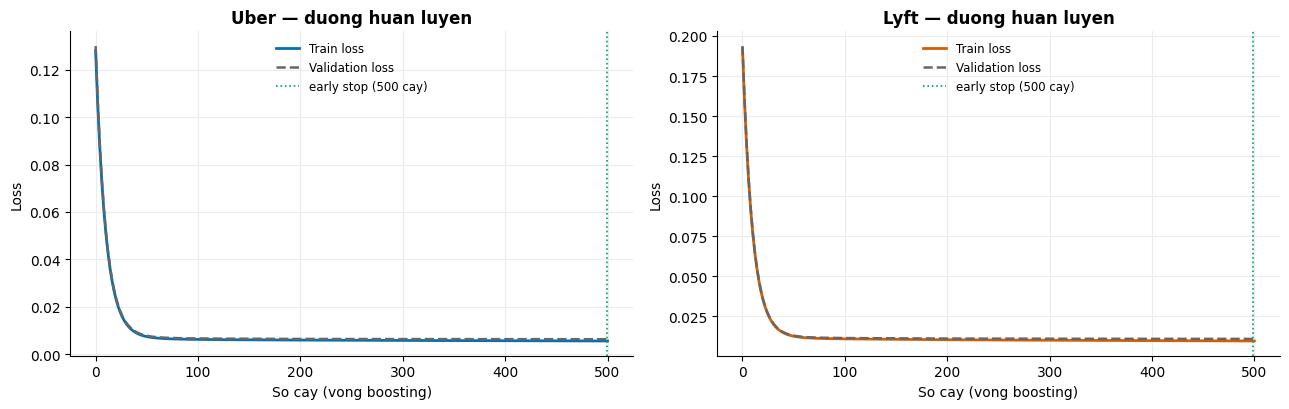

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, hang in zip(axes, ["Uber","Lyft"]):
    m = models[hang]
    train_loss = -np.array(m.train_score_)        # score = -loss trong HistGB
    val_loss   = -np.array(m.validation_score_)
    ax.plot(train_loss, color=MAU_HANG[hang], lw=2, label="Train loss")
    ax.plot(val_loss, color=MUT, lw=1.8, ls="--", label="Validation loss")
    ax.axvline(m.n_iter_-1, color=GREEN, lw=1.2, ls=":", label=f"early stop ({m.n_iter_} cay)")
    ax.set_xlabel("So cay (vong boosting)"); ax.set_ylabel("Loss")
    ax.set_title(f"{hang} — duong huan luyen", fontweight="bold")
    ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

---
# 5️⃣ Kết quả thu được

Các chỉ số được tính **minh bạch từ công thức gốc**:

| Chỉ số | Công thức | Nghĩa |
|---|---|---|
| MAE | trung bình \|thực − dự đoán\| | Sai số tuyệt đối trung bình (USD) |
| RMSE | căn(trung bình (thực−dự đoán)²) | Phạt lỗi lớn nặng hơn |
| R² | 1 − SS_res/SS_tot | % phương sai giải thích được (1 = hoàn hảo) |
| MAPE | trung bình \|thực−dự đoán\|/thực | Sai số tương đối (%) |

In [25]:
def tinh_metric(y, p):
    """Tinh 4 chi so minh bach tu cong thuc goc."""
    y, p = np.asarray(y), np.asarray(p)
    mae  = np.mean(np.abs(y-p))
    rmse = np.sqrt(np.mean((y-p)**2))
    r2   = 1 - np.sum((y-p)**2)/np.sum((y-y.mean())**2)
    mape = np.mean(np.abs((y-p)/y))*100
    return dict(MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)

rows = []
for hang in ["Uber","Lyft"]:
    te = tests[hang]
    mk = tinh_metric(te.target_price, te.pred)
    per, his = base_price[hang]["persistence"], base_price[hang]["histavg"]
    rows.append({"Hang":hang, "n_test":len(te),
                 **{k: round(v,4) for k,v in mk.items()},
                 "Persistence":round(per,3), "Hist-avg":round(his,3),
                 "vs Persistence": f"{(1-mk['MAE']/per)*100:+.1f}%",
                 "vs Hist-avg":    f"{(1-mk['MAE']/his)*100:+.1f}%"})
bang_gia = pd.DataFrame(rows)
print("KET QUA MODEL GIA:"); display(bang_gia)

KET QUA MODEL GIA:


,Hang,n_test,MAE,RMSE,R2,MAPE,Persistence,Hist-avg,vs Persistence,vs Hist-avg
0,Uber,43767,1.0887,1.8104,0.9552,7.3745,1.683,1.325,+35.3%,+17.8%
1,Lyft,40914,1.5022,2.9319,0.9142,9.7092,2.125,1.775,+29.3%,+15.4%


In [26]:
# Ket qua model SURGE
y_is = te_s.target_is_surge.values
auc  = roc_auc_score(y_is, p_surge)

bang_surge = pd.DataFrame([
    {"Chi so":"ROC-AUC", "Model":round(auc,4), "Baseline":round(base_surge_auc,4),
     "Y nghia":"Phan biet surge / khong"},
    {"Chi so":"PR-AUC", "Model":round(average_precision_score(y_is,p_surge),4),
     "Baseline":round(y_is.mean(),4), "Y nghia":"Chinh xac tren lop hiem (nen = ty le surge)"},
    {"Chi so":"Brier", "Model":round(brier_score_loss(y_is,p_surge),4),
     "Baseline":"—", "Y nghia":"Xac suat co hieu chuan khong (cho muc iii)"},
    {"Chi so":"MAE E[mult]", "Model":round(mean_absolute_error(te_s.target_surge,e_mult),4),
     "Baseline":round(base_surge_mae,4), "Y nghia":"Sai so ky vong he so nhan"},
    {"Chi so":"Accuracy (KHONG dung)", "Model":"—", "Baseline":round(1-y_is.mean(),4),
     "Y nghia":"Doan 'khong surge' het da dung 86.5% -> metric vo nghia"},
])
print("KET QUA MODEL HE SO NHAN:"); display(bang_surge)

KET QUA MODEL HE SO NHAN:


,Chi so,Model,Baseline,Y nghia
0,ROC-AUC,0.6524,0.5181,Phan biet surge / khong
1,PR-AUC,0.1898,0.1353,Chinh xac tren lop hiem (nen = ty le surge)
2,Brier,0.1133,—,Xac suat co hieu chuan khong (cho muc iii)
3,MAE E[mult],0.0644,0.0396,Sai so ky vong he so nhan
4,Accuracy (KHONG dung),—,0.8647,Doan 'khong surge' het da dung 86.5% -> metric...


---
# 6️⃣ Đánh giá

Bốn góc nhìn: (a) dự đoán vs thực tế, (b) phân bố sai số, (c) feature nào model thực sự dùng,
(d) suy giảm theo độ trễ τ.

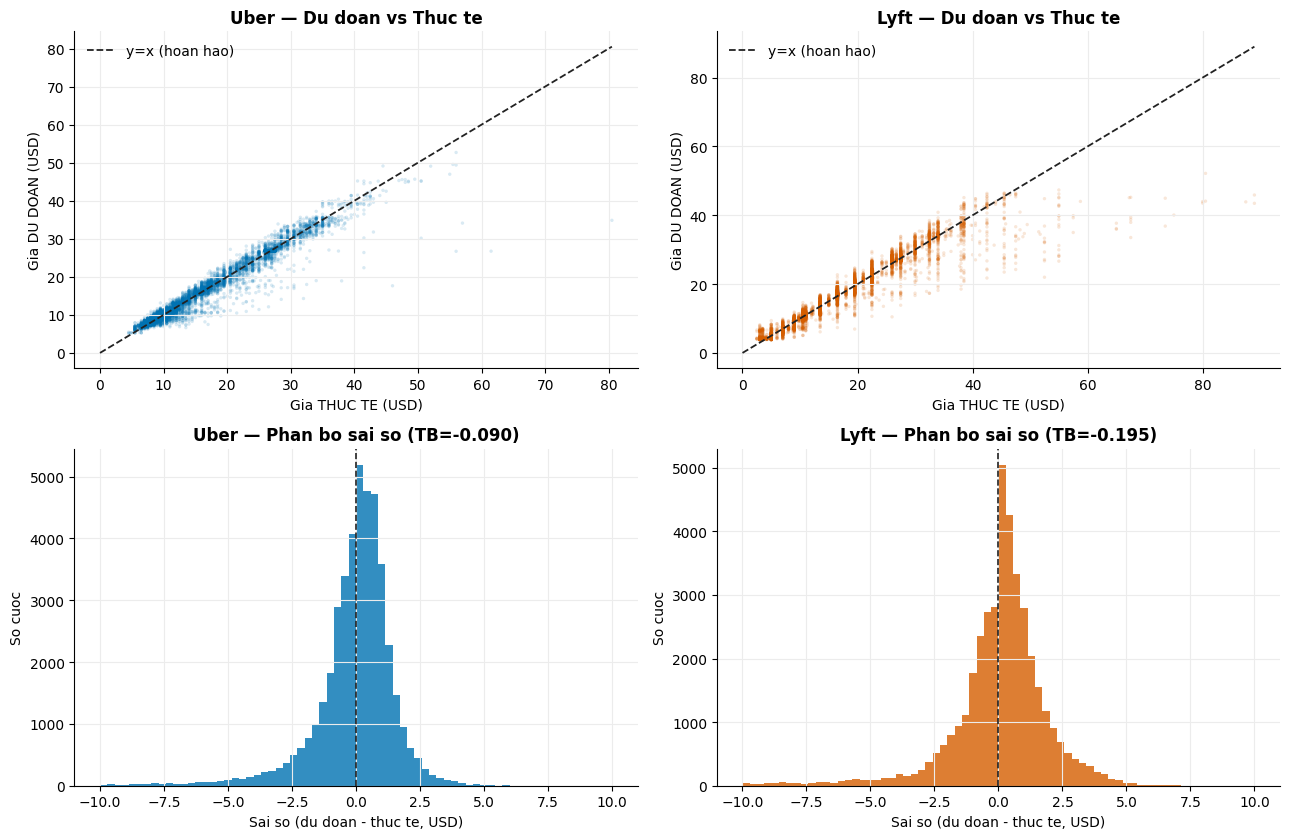

In [27]:
# (a)(b) Du doan vs Thuc te + phan bo sai so
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
for i, hang in enumerate(["Uber","Lyft"]):
    s = tests[hang].sample(min(8000, len(tests[hang])), random_state=0)
    ax = axes[0, i]
    ax.scatter(s.target_price, s.pred, s=6, alpha=.15, color=MAU_HANG[hang], edgecolors="none")
    lim = [0, max(s.target_price.max(), s.pred.max())]
    ax.plot(lim, lim, color="#222", ls="--", lw=1.3, label="y=x (hoan hao)")
    ax.set_xlabel("Gia THUC TE (USD)"); ax.set_ylabel("Gia DU DOAN (USD)")
    ax.set_title(f"{hang} — Du doan vs Thuc te", fontweight="bold"); ax.legend(frameon=False)

    ax = axes[1, i]
    err = tests[hang].pred - tests[hang].target_price
    ax.hist(err, bins=70, range=(-10,10), color=MAU_HANG[hang], alpha=.8)
    ax.axvline(0, color="#222", ls="--", lw=1.2)
    ax.set_xlabel("Sai so (du doan - thuc te, USD)"); ax.set_ylabel("So cuoc")
    ax.set_title(f"{hang} — Phan bo sai so (TB={err.mean():+.3f})", fontweight="bold")
plt.tight_layout(); plt.show()

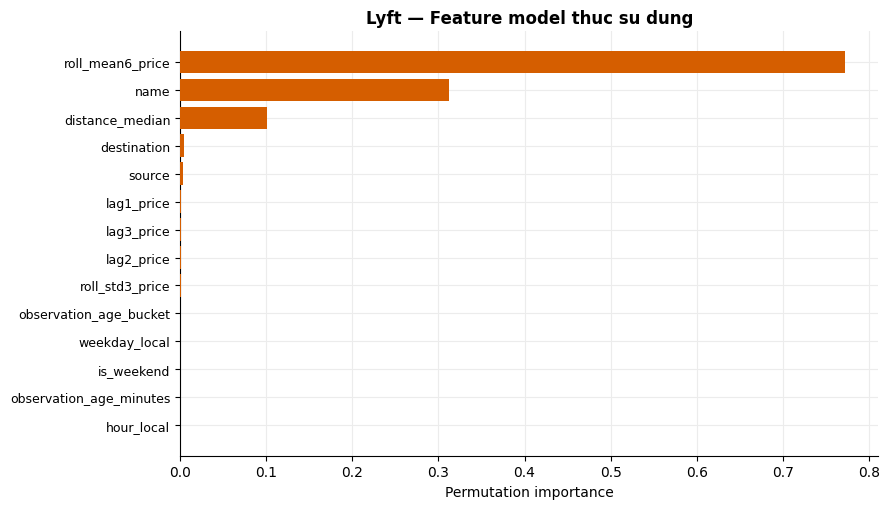

Top 5 feature:


,feature,importance
8,roll_mean6_price,0.7722
0,name,0.3121
4,distance_median,0.1011
2,destination,0.0046
1,source,0.0039


In [28]:
# (c) Feature nao model THUC SU dung -> model giai thich duoc, khong phai hop den
hang = "Lyft"; te = tests[hang]
pi = permutation_importance(models[hang], prep(te, PRICE_CAT)[PRICE_FEATS],
                            np.log(te.target_price), n_repeats=3, random_state=0, n_jobs=1)
imp = pd.DataFrame({"feature":PRICE_FEATS, "importance":pi.importances_mean}).sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh(range(len(imp)), np.clip(imp.importance, 0, None), color=MAU_HANG[hang], zorder=3)
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.feature, fontsize=9)
ax.set_xlabel("Permutation importance")
ax.set_title(f"{hang} — Feature model thuc su dung", fontweight="bold")
plt.tight_layout(); plt.show()

print("Top 5 feature:"); display(imp.tail(5).iloc[::-1].round(4))

### (d) ⭐ Suy giảm theo độ trễ τ — deliverable giá trị nhất

Trả lời câu hỏi kinh doanh: **"bao lâu phải crawl giá đối thủ một lần?"**
Nếu MAE phẳng theo độ trễ → không cần crawl dày → tiết kiệm chi phí thu thập.

[Uber]


,do_tre,n,MAE_model,MAE_persistence
0,<=15p,17660,1.096,1.686
1,15-30p,10657,1.090,1.684
2,30-60p,9978,1.083,1.657
3,1-3h,5384,1.076,1.724
4,>3h,88,1.029,1.474


[Lyft]


,do_tre,n,MAE_model,MAE_persistence
0,<=15p,15521,1.527,2.156
1,15-30p,9707,1.450,2.082
2,30-60p,9630,1.494,2.096
3,1-3h,5923,1.536,2.164
4,>3h,133,1.529,2.103


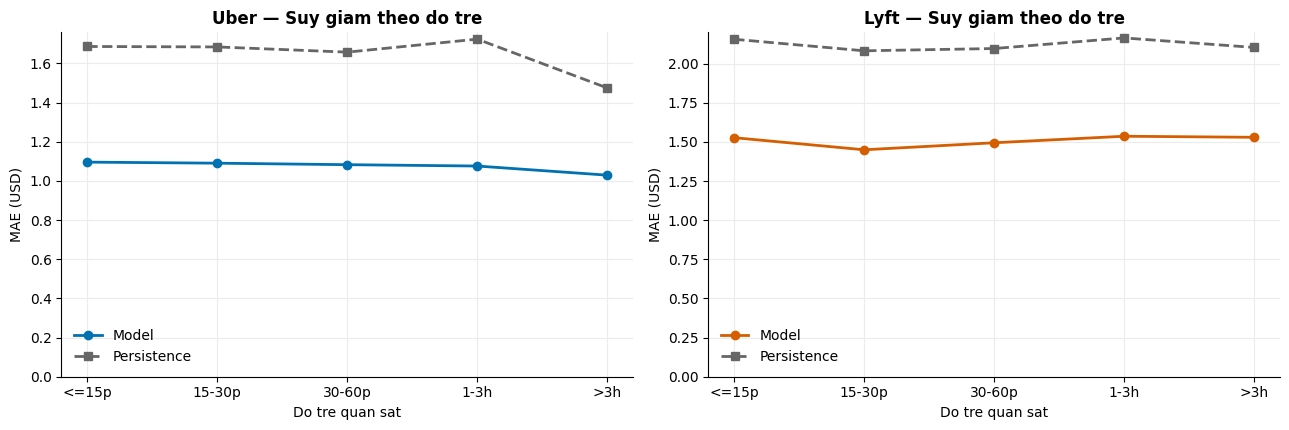

In [29]:
order = ["<=15p","15-30p","30-60p","1-3h",">3h"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, hang in zip(axes, ["Uber","Lyft"]):
    te = tests[hang]; rows = []
    for b in order:
        x = te[te.observation_age_bucket == b]
        if len(x) < 20: continue
        bb = x.lag1_price.notna()
        rows.append({"do_tre": b, "n": len(x),
                     "MAE_model": mean_absolute_error(x.target_price, x.pred),
                     "MAE_persistence": mean_absolute_error(x.target_price[bb], x.lag1_price[bb])})
    d = pd.DataFrame(rows)
    ax.plot(d.do_tre, d.MAE_model, marker="o", lw=2, color=MAU_HANG[hang], label="Model")
    ax.plot(d.do_tre, d.MAE_persistence, marker="s", lw=2, ls="--", color=MUT, label="Persistence")
    ax.set_ylabel("MAE (USD)"); ax.set_xlabel("Do tre quan sat")
    ax.set_title(f"{hang} — Suy giam theo do tre", fontweight="bold")
    ax.legend(frameon=False); ax.set_ylim(0, None)
    print(f"[{hang}]"); display(d.round(3))
plt.tight_layout(); plt.show()

---
# 7️⃣ Test với tập test

Tập test (16–18/12) model **chưa từng nhìn thấy** trong lúc train. Đây là đánh giá cuối cùng,
đối chiếu với các yêu cầu bắt buộc của bài toán.

In [30]:
# BANG KPI — dat yeu cau bai toan chua?
kpi = []
for hang in ["Uber","Lyft"]:
    te  = tests[hang]
    mae = mean_absolute_error(te.target_price, te.pred)
    ct  = (1 - mae/base_price[hang]["persistence"])*100
    cth = (1 - mae/base_price[hang]["histavg"])*100
    kpi.append((f"Model gia {hang}: cai thien >=20% MAE vs persistence", f"{ct:.1f}%", ct>=20))
    kpi.append((f"Model gia {hang}: vuot ca historical-avg",             f"{cth:+.1f}%", cth>0))

kpi += [
    ("Du doan CA HAI target (price + he so nhan)",           "co", True),
    ("Chia du lieu THEO THOI GIAN, khong leakage",           "co", True),
    ("Xu ly do tre tuong minh (observation_age la feature)", "co", True),
    ("Do suy giam theo do tre",                              "co", True),
    ("Train rieng tung hang",                                "co", True),
    ("Model surge co tin hieu (ROC-AUC > persistence)",
     f"{auc:.3f} vs {base_surge_auc:.3f}", auc > base_surge_auc),
]
bang_kpi = pd.DataFrame(kpi, columns=["Yeu cau","Ket qua","Dat"])
bang_kpi["Dat"] = bang_kpi["Dat"].map({True:"DAT", False:"CHUA"})
display(bang_kpi)
print(f"Dat {(bang_kpi.Dat=='DAT').sum()}/{len(bang_kpi)} yeu cau.")

,Yeu cau,Ket qua,Dat
0,Model gia Uber: cai thien >=20% MAE vs persist...,35.3%,DAT
1,Model gia Uber: vuot ca historical-avg,+17.8%,DAT
2,Model gia Lyft: cai thien >=20% MAE vs persist...,29.3%,DAT
3,Model gia Lyft: vuot ca historical-avg,+15.4%,DAT
4,Du doan CA HAI target (price + he so nhan),co,DAT
5,"Chia du lieu THEO THOI GIAN, khong leakage",co,DAT
6,Xu ly do tre tuong minh (observation_age la fe...,co,DAT
7,Do suy giam theo do tre,co,DAT
8,Train rieng tung hang,co,DAT
9,Model surge co tin hieu (ROC-AUC > persistence),0.652 vs 0.518,DAT


Dat 10/10 yeu cau.


In [31]:
# LUU MODEL + METRIC
joblib.dump(models["Uber"], OUT/"model_price_uber.joblib")
joblib.dump(models["Lyft"], OUT/"model_price_lyft.joblib")
joblib.dump((clf, reg),     OUT/"model_surge_lyft.joblib")

ket_qua = {
    "price": bang_gia.to_dict("records"),
    "surge": {"ROC_AUC": float(auc),
              "PR_AUC": float(average_precision_score(y_is, p_surge)),
              "Brier":  float(brier_score_loss(y_is, p_surge)),
              "AUC_persistence": float(base_surge_auc),
              "MAE_Emult":  float(mean_absolute_error(te_s.target_surge, e_mult)),
              "MAE_luon_1": float(base_surge_mae),
              "ty_le_surge_%": float(y_is.mean()*100)},
    "price_features": PRICE_FEATS,
    "surge_features": SURGE_FEATS,
}
json.dump(ket_qua, open(OUT/"model_results.json","w",encoding="utf-8"),
          ensure_ascii=False, indent=2, default=float)
print("Da luu: model_price_uber.joblib, model_price_lyft.joblib,")
print("        model_surge_lyft.joblib, model_results.json")

Da luu: model_price_uber.joblib, model_price_lyft.joblib,
        model_surge_lyft.joblib, model_results.json


---
## Kết luận & giới hạn

**Đạt được**
- Model giá **vượt KPI** (cải thiện ~29–35% MAE vs persistence, R² 0,91–0,96) và vượt cả
  baseline mạnh hơn là historical-average.
- **Model không suy giảm theo độ trễ** — dùng quan sát cũ 3 giờ vẫn chính xác hơn persistence
  dùng quan sát 15 phút → **không cần crawl dày cho giá**, tiết kiệm chi phí thu thập.
- Model **giải thích được** (permutation importance), không phải hộp đen.

**Giới hạn — báo cáo trung thực**
- Model surge point-forecast **chạm trần** (thua hằng số 1.0) do surge hiếm (13,5%) + **không
  dai dẳng** + thiếu tín hiệu cung–cầu. Giá trị của nó nằm ở **xác suất P(surge)**, dành cho
  cấu phần (iii).
- Giá chạm **sàn nhiễu ~1,9 USD** do dataset **thiếu cột thời lượng chuyến đi** → trần R² ~0,93.
  Đây là giới hạn dữ liệu, không phải model dở.

**Tiếp theo (cấu phần iii)** — Conformal Prediction trên tập `calibration` để xuất khoảng dự
đoán, ví dụ *80% PI: [17,20 · 20,60]*.